In [1]:

import os, sys
os.chdir('..')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
import seaborn as sns

sys.path.append('.')
from trajectory import World
from constants import *

In [3]:
from toroidal_coordinates.toroidal_lifting import toroidal_lifting_distance_upgrade
from affine_transform.score_mismatch import score_mismatch
from affine_transform.get_transform_mat import get_transform_mat, apply_transform_mat

## Compare the error of one path lifting to baseline errors from 100 simulations

In [27]:
for num_holes in range(3):
    
    random_traj = pickle.load(open(os.path.join(DATA_ROOT, "affine_transform", f"random_walk_{num_holes}holes.pkl"), "rb"))
    traj = pickle.load(open(f"data/simulated_trajectory/random_walk_{num_holes}holes.pkl", "rb"))[0]
    mismatch_scores = []
    for i in range(len(random_traj)):
        aligned_random = apply_transform_mat(random_traj[i], get_transform_mat(traj, random_traj[i]))
        mismatch_scores.append(score_mismatch(traj, aligned_random, 100))
    pickle.dump(mismatch_scores, open(os.path.join(DATA_ROOT, "affine_transform", f"random_mismatch_scores_{num_holes}holes_update.pkl"), "wb"))

100
100
100


In [10]:
all_lifted_mismatch = []

for num_holes in range(3):
    with np.load(os.path.join("/data/yyao01/GridDecode/grid_fields/", f"world_{num_holes}holes", "toroidal_coords_dreimac.npz")) as data:
        cir_coords = data["coords"]
    lifted = toroidal_lifting_distance_upgrade(cir_coords.copy())
    #with np.load(os.path.join(GRID_FIELDS_PATH, f"world_{num_holes}holes", "toroidal_coords_dreimac.npz")) as data:


    traj = pickle.load(open(f"data/simulated_trajectory/random_walk_{num_holes}holes.pkl", "rb"))[0]
    matrix = get_transform_mat(lifted, traj)
    recovered_path = apply_transform_mat(lifted, matrix)
    lifted_mismatch = score_mismatch(traj, recovered_path, 100)
    all_lifted_mismatch.append(lifted_mismatch)

DISTANCE_THRESHOLD: 4.24292283813971
DISTANCE_THRESHOLD: 4.209510854922103
DISTANCE_THRESHOLD: 4.244901166880007


In [11]:
from scipy.stats import ttest_ind, ttest_1samp
for i in range(3):
    mismatch_scores = pickle.load(open(os.path.join(DATA_ROOT, "affine_transform", f"random_mismatch_scores_{i}holes_update.pkl"), "rb"))
    result = ttest_1samp(
        mismatch_scores,
        all_lifted_mismatch[i]
    )
    print(f'{i}holes: {result}')

0holes: TtestResult(statistic=74.9132610816954, pvalue=5.413147837273514e-89, df=99)
1holes: TtestResult(statistic=56.170606591228356, pvalue=6.729268767512769e-77, df=99)
2holes: TtestResult(statistic=85.91840242043769, pvalue=8.489478141816417e-95, df=99)


In [12]:
from scipy.stats import norm

def compute_z_score(x, pop: np.ndarray) -> tuple[float, float]:
    mu = np.mean(pop)
    s = np.std(pop)
    
    z = (x - mu) / s
    p = float(2 * (1 - norm.cdf(np.abs(z))))
    return z, p

In [13]:
for i in range(3):
    mismatch_scores = pickle.load(open(os.path.join(DATA_ROOT, "affine_transform", f"random_mismatch_scores_{i}holes.pkl"), "rb"))
    z_score, pvalue = compute_z_score(all_lifted_mismatch[i], np.array(mismatch_scores))
    print(f'{i}holes: z-score = {z_score}\tp-value = {pvalue}')

0holes: z-score = -7.52906602514901	p-value = 5.10702591327572e-14
1holes: z-score = -5.645358373023284	p-value = 1.6483751918983103e-08
2holes: z-score = -8.63512434591985	p-value = 0.0


## Plot

In [14]:
random_error0 = pickle.load(open(os.path.join(DATA_ROOT, "affine_transform", f"random_mismatch_scores_0holes.pkl"), "rb"))
random_error1 = pickle.load(open(os.path.join(DATA_ROOT, "affine_transform", f"random_mismatch_scores_1holes.pkl"), "rb"))
random_error2 = pickle.load(open(os.path.join(DATA_ROOT, "affine_transform", f"random_mismatch_scores_2holes.pkl"), "rb"))

In [29]:
# load the lifting results from 10 independent simulations

npz_path = "/data/hyoon/GridDecode/grid_fields/random_walk_0holes_25000_n0_lifting_results.npz"

with np.load(npz_path) as data:
    processed_trace = data["processed_trace"]
    lifted_coord_gardner = data["lifted_coord_gardner"]
    score_gardner = data["score_gardner"]

print("processed_trace shape:", processed_trace.shape)
print("lifted_coord_gardner shape:", lifted_coord_gardner.shape)
print("score_gardner:", score_gardner)

processed_trace shape: (599999, 2)
lifted_coord_gardner shape: (599999, 2)
score_gardner: 0.01261791805781532


In [38]:
scores0 = []
scores1 = []
scores2 = []

base_dir = "/data/hyoon/GridDecode/grid_fields/"

for holes in [0, 1, 2]:
    for n in range(10):  # n0 ... n9
        fname = f"random_walk_{holes}holes_25000_n{n}_lifting_results.npz"
        fpath = os.path.join(base_dir, fname)

        with np.load(fpath) as data:
            score = float(np.ravel(data["score_gardner"])[0])
            if holes == 0:
                scores0.append(score)
            elif holes == 1:
                scores1.append(score)
            elif holes == 2:
                scores2.append(score)

In [39]:
all_lifted_mismatch = dict()
#
all_lifted_mismatch[0] = scores0
all_lifted_mismatch[1] = scores1
all_lifted_mismatch[2] = scores2

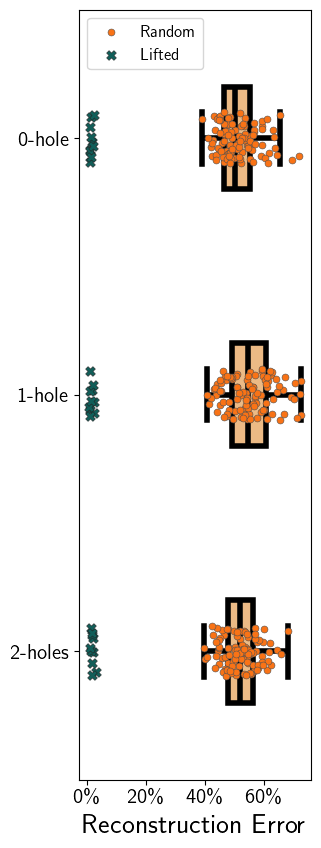

In [40]:
from matplotlib.ticker import PercentFormatter, FuncFormatter

plt.figure(figsize=(3, 10))
for num_holes in range(3):
    random_mismatch_distribution = pickle.load(open(os.path.join(DATA_ROOT, "affine_transform", f"random_mismatch_scores_{num_holes}holes_update.pkl"), "rb"))
    if num_holes == 1:
        random_mismatch_distribution.remove(max(random_mismatch_distribution))

    # Ensure lifted scores are plain Python floats for seaborn plotting.
    lifted_mismatch = [float(x) for x in all_lifted_mismatch[num_holes]]
    
    sns.stripplot(
        y=[num_holes] * len(random_mismatch_distribution),
        x=random_mismatch_distribution,
        color='#F97316',
        #alpha=0.8,
        size=5,
        jitter=True,
        orient='h',
        linewidth=0.4,
        label='Random',
    )
    sns.stripplot(
        y=[num_holes] * len(lifted_mismatch),
        x=lifted_mismatch,
        color='#115E59',
        #alpha=0.8,
        size=7,
        jitter=True,
        orient='h',
        linewidth=0.4,
        marker='X',
        label='Lifted',
    )
    sns.boxplot(
        y=[num_holes] * len(random_mismatch_distribution),
        x=random_mismatch_distribution,
        color='#FDBA74',
        width=0.4,
        fliersize=0,
        linewidth=4,
        orient='h',
        boxprops=dict(edgecolor='k'),
        whiskerprops=dict(color='k'),
        capprops=dict(color="black"),
        medianprops=dict(color="black"),
    )

plt.gca().xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))

plt.yticks([0, 1, 2], ['0-hole', '1-hole', '2-holes'], fontsize=15)
plt.xticks(fontsize=15)
plt.xlabel('Reconstruction Error', fontsize=20)
plt.ylabel('')

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))

plt.legend(by_label.values(), by_label.keys(),loc='upper left', fontsize=12)
#plt.savefig(os.path.join("figures", 'simulation', f'errors.pdf'), bbox_inches='tight', transparent=True)